# UNET WITH PRETRAINED RESNET ENCODER (Pretrained Resnet50 on Imagenet1k - best.pt)

In [1]:
import math
import os
import random
import time
from datetime import datetime

import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
import scipy
from PIL import Image
import pandas as pd

from typing import Sequence


import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, tv_tensors
from torchvision.transforms import v2
import torchvision.transforms.v2.functional as TF
from torchvision.utils import make_grid

In [2]:
# Seed every RNG so runs are comparable: CIFAR-10 seed variance (~±0.3-0.7%)
# is the same magnitude as many single-change effects.
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

## Data Loading

In [3]:
# Hyper parameters
# Data
IMAGE_SIZE = 128
RESIZE_SIZE = round(IMAGE_SIZE * 1.125) # 144
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
CHANNELS = 3
NUM_CLASSES = 3       
CLASS_NAMES = ("pet", "background", "boundary")

# Training
BATCH_SIZE = 32
EPOCHS = 100
WARMUP_EPOCHS = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

VAL_FRACTION = 0.2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")

torch.backends.cudnn.benchmark = True  # fixed input size -> let cudnn pick the fastest kernels

set_seed(SEED)  # seed right before weight init so the run is reproducible

NUM_WORKERS = min(8, os.cpu_count() or 1)
PIN_MEMORY = device.type == "cuda"

cuda NVIDIA GeForce RTX 5080


In [4]:
class PreparePetSample:
    def __call__(self, image, mask):
        image = tv_tensors.Image(image)
        mask = tv_tensors.Mask(mask)
        return image, mask

class ConvertToClassMask:
    def __call__(self, image, mask):
        # From: 1 = pet, 2 = background, 3 = boundary.
        # To: 0 = pet, 1 = background, 2 = boundary.
        mask = mask.to(torch.long) - 1

        # Per-sample target must be [H, W], not [1, H, W].
        if mask.ndim == 3 and mask.shape[0] == 1:
            mask = mask.squeeze(0)

        if mask.ndim != 2:
            raise ValueError(
                f"Expected a 2D mask, got {tuple(mask.shape)}"
            )

        if mask.min().item() < 0 or mask.max().item() >= NUM_CLASSES:
            raise ValueError("Mask contains unexpected class IDs.")

        return image, mask

train_transform = v2.Compose([

    PreparePetSample(),

    # Resize slightly larger before randomly cropping.
    v2.Resize((RESIZE_SIZE, RESIZE_SIZE), antialias=True),

    # Applied identically to both image and mask.
    v2.RandomCrop((IMAGE_SIZE, IMAGE_SIZE)),

    v2.RandomHorizontalFlip(p=0.5),

    # Converts image to float32 [0, 1].
    # Keeps the mask as an integer mask until binary conversion.
    v2.ToDtype({
        tv_tensors.Image: torch.float32,
        tv_tensors.Mask: torch.long,
    }, scale=True),

    # v2 normalizes images, leaving Mask tensors unchanged.
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),

    ConvertToClassMask(),
])


eval_transform = v2.Compose([

    PreparePetSample(),

    v2.Resize((IMAGE_SIZE, IMAGE_SIZE), antialias=True),

    v2.ToDtype({
        tv_tensors.Image: torch.float32,
        tv_tensors.Mask: torch.long,
    }, scale=True),

    # v2 normalizes images, leaving Mask tensors unchanged.
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    
    ConvertToClassMask(),
])

train_base = datasets.OxfordIIITPet(
    root="dataset/",
    split="trainval",
    target_types="segmentation",
    transforms=train_transform,
    download=True,
)

eval_base = datasets.OxfordIIITPet(
    root="dataset/",
    split="trainval",
    target_types="segmentation",
    transforms=eval_transform,
    download=True,
)

test_dataset = datasets.OxfordIIITPet(
    root="dataset/",
    split="test",
    target_types="segmentation",
    transforms=eval_transform,
    download=True,
)

In [5]:
split_generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(
    len(train_base),
    generator=split_generator,
).tolist()

num_val = round(VAL_FRACTION * len(indices))
val_indices = indices[:num_val]
train_indices = indices[num_val:]

train_dataset = Subset(train_base, train_indices)
val_dataset = Subset(eval_base, val_indices)

eval_train_dataset = Subset(
    eval_base,
    train_indices[:min(1000, len(train_indices))],
)
# 70 - 20 - 10


In [6]:
def make_loader(dataset, shuffle=False):
    return DataLoader(
        dataset=dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=NUM_WORKERS > 0,
        worker_init_fn=seed_worker,
        generator=torch.Generator().manual_seed(SEED),
        drop_last=False,
    )

In [7]:
train_loader = make_loader(train_dataset, shuffle=True)
val_loader = make_loader(val_dataset)
test_loader = make_loader(test_dataset)
eval_train_loader = make_loader(eval_train_dataset)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Training evaluation subset:", len(eval_train_dataset))


Training images: 2944
Validation images: 736
Test images: 3669
Training evaluation subset: 1000


In [8]:
images, masks = next(iter(val_loader))

print("Image shape:", images.shape)   # [B, 3, 128, 128]
print("Mask shape:", masks.shape)     # [B, 128, 128]
print("Image dtype:", images.dtype)   # float32
print("Mask dtype:", masks.dtype)     # int64
print("Mask class IDs:", torch.unique(masks))

Image shape: torch.Size([32, 3, 128, 128])
Mask shape: torch.Size([32, 128, 128])
Image dtype: torch.float32
Mask dtype: torch.int64
Mask class IDs: tensor([0, 1, 2])


## Training

### Unet_Resnet (from pretrained Resnet50 on Imagenet1k - ./checkpoints/20260922-145555_resnet50_best.pt)

#### Setup Resnet50 encoder

In [9]:
from models.resnet import *

set_seed(SEED)
resnet50_checkpoint_path = "./checkpoints/20260922-145555_resnet50_best.pt"
layers = [3, 4, 6, 3]
pretrained_resnet = Resnet(BottleneckResidualBlock, layers=layers, in_channels=3, num_classes= 1000)

# Load pretrained weights
checkpoint = torch.load(
    resnet50_checkpoint_path,
    map_location="cpu",
    weights_only=True,
)

pretrained_resnet.load_state_dict(
    checkpoint["model_state"],
    strict=True,
)

<All keys matched successfully>

In [10]:
from models.unet_resnet import UnetResnet
unet_resnet = UnetResnet(pretrained_resnet=pretrained_resnet, num_classes=NUM_CLASSES).to(device)

unet_resnet = unet_resnet.to(memory_format=torch.channels_last)

In [11]:
unet_resnet

UnetResnet(
  (encoder): ResnetEncoder(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
    )
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (stages): Sequential(
      (0): Sequential(
        (0): BottleneckResidualBlock(
          (block): Sequential(
            (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): ReLU()
            (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (5): ReLU()
            (6): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)

In [12]:
# finetuned the full model
unet_resnet.requires_grad_(True)

UnetResnet(
  (encoder): ResnetEncoder(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
    )
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (stages): Sequential(
      (0): Sequential(
        (0): BottleneckResidualBlock(
          (block): Sequential(
            (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): ReLU()
            (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (5): ReLU()
            (6): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)

In [13]:
# Raw logits [B, 3, H, W] + integer targets [B, H, W].
criterion = nn.CrossEntropyLoss()

decay, no_decay = [], []
for name, parameter in unet_resnet.named_parameters():
    if not parameter.requires_grad:
        continue

    if parameter.ndim <= 1 or name.endswith(".bias"):
        no_decay.append(parameter)
    else:
        decay.append(parameter)


optimizer = optim.AdamW(
    [
        {"params": decay, "weight_decay": WEIGHT_DECAY},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=LEARNING_RATE,
)

warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=0.0)
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_EPOCHS])

### Metrics

Dice = % segmentation overlap => deal with fine structure + small regions + imbalanced background/foreground(mitigate extreme background dominance)

IoU = same as dice but stricter evaluation => heavily penalize FP and FN

https://veradp-ai.com/iou-vs-dice/

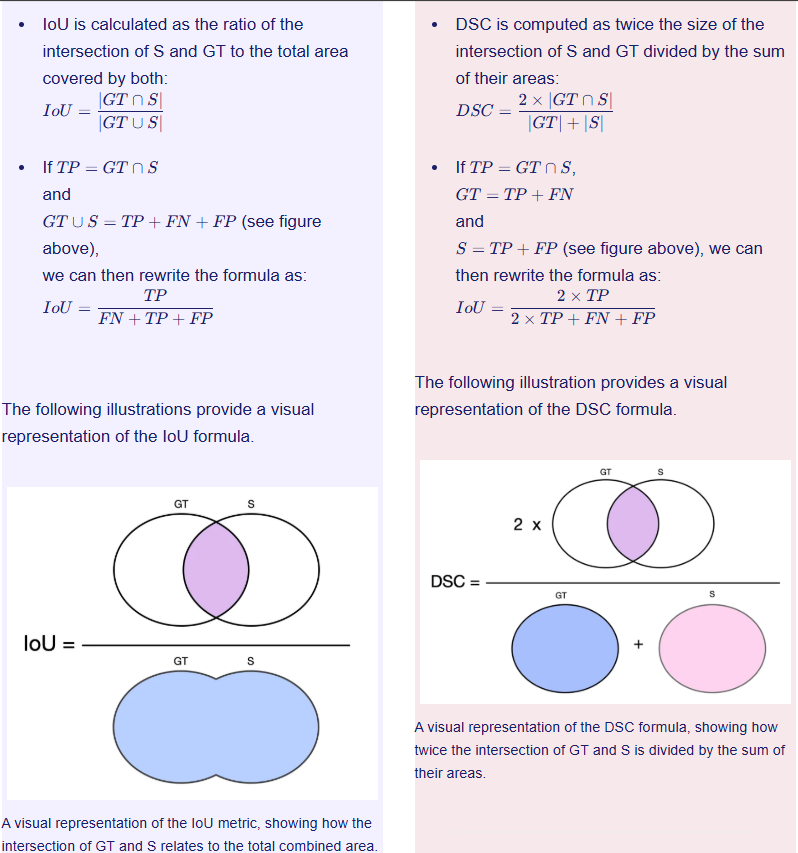

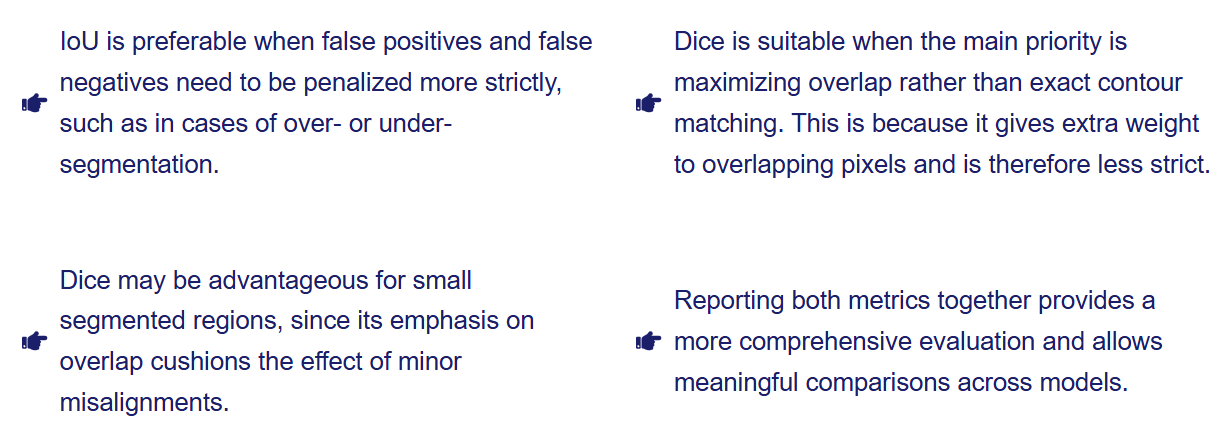

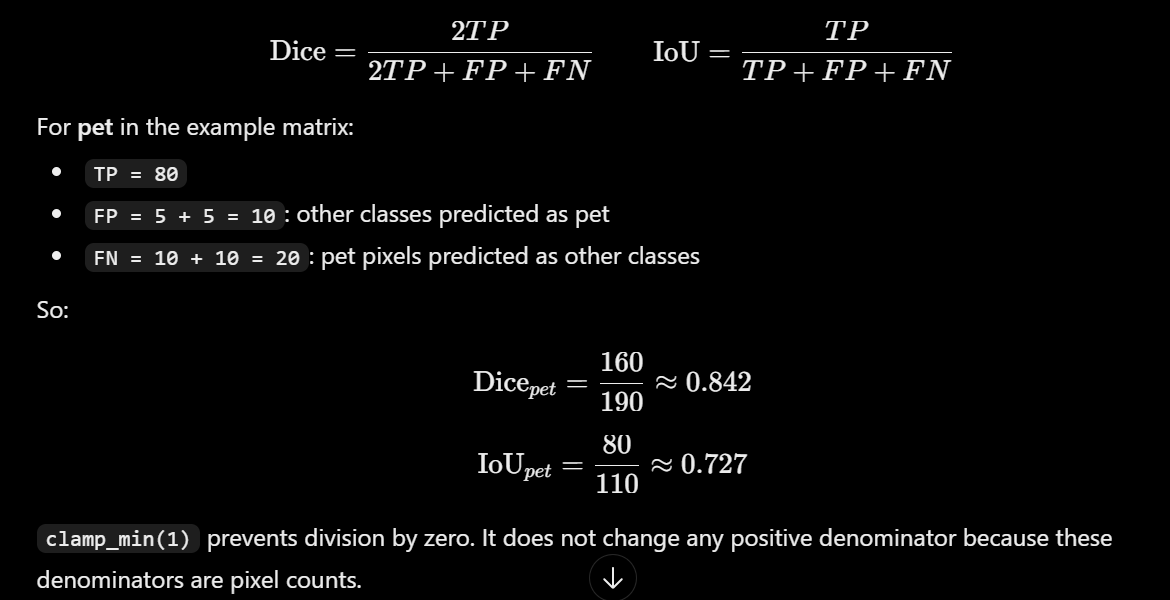

In [14]:
# Rows of confusion = ground truth; columns = prediction.
# Dice/IoU are dataset-level per-class metrics, macro averaged across classes
# present in either predictions or targets. Absent classes get NaN individually.
@torch.inference_mode()
def evaluate(loader, model):
    model.eval()
    confusion = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.int64, device=device)
    for x, y in loader:
        x = x.to(device, non_blocking=True, memory_format=torch.channels_last)
        y = y.to(device, non_blocking=True)
        if y.ndim != 3 or y.dtype != torch.long:
            raise ValueError("Expected int64 masks [B,H,W]. Restart kernel and Run All.")
        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(x)
        if tuple(logits.shape) != (y.shape[0], NUM_CLASSES, *y.shape[-2:]):
            raise ValueError("Expected logits [B,NUM_CLASSES,H,W].")
        preds = logits.argmax(dim=1)
        encoded = y.reshape(-1) * NUM_CLASSES + preds.reshape(-1)
        confusion += torch.bincount(encoded, minlength=NUM_CLASSES**2).reshape(NUM_CLASSES, NUM_CLASSES)

    counts = confusion.double()
    if counts.sum().item() == 0:
        raise ValueError("Evaluation loader contains no pixels.")
    tp = counts.diag()
    total = counts.sum(0) + counts.sum(1)
    union = total - tp
    present = union > 0
    dice = 2 * tp / total.clamp_min(1)
    iou = tp / union.clamp_min(1)
    result = {
        "pixel_acc": (tp.sum() / counts.sum()).item(),
        "dice": dice[present].mean().item(),
        "iou": iou[present].mean().item(),
    }
    for i, name in enumerate(CLASS_NAMES):
        result[f"dice_{name}"] = dice[i].item() if present[i].item() else float("nan")
        result[f"iou_{name}"] = iou[i].item() if present[i].item() else float("nan")
    return result


@torch.inference_mode()
def log_predictions(writer, model, loader, epoch, max_images=8):
    model.eval()
    x, y = next(iter(loader))
    x = x[:max_images].to(device, non_blocking=True, memory_format=torch.channels_last)
    y = y[:max_images].long().cpu()
    with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
        logits = model(x)
    preds = logits.argmax(dim=1).cpu()
    mean = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1)
    images = (x.float().cpu() * std + mean).clamp(0, 1)
    # Pet green, background black, boundary yellow.
    palette = torch.tensor([[0., 1., 0.], [0., 0., 0.], [1., 1., 0.]])
    targets_rgb = palette[y].permute(0, 3, 1, 2)
    preds_rgb = palette[preds].permute(0, 3, 1, 2)
    # Three rows: input, ground truth, prediction.
    panel = make_grid(torch.cat([images, targets_rgb, preds_rgb]), nrow=len(images))
    writer.add_image("Predictions/image_gt_pred", panel, epoch)

### Run

In [15]:
def run(
    model,
    optimizer,
    scheduler,
    criterion,
    epochs,
    writer,
    run_name,
    log_images_every=5,
):
    if epochs < 1:
        raise ValueError("epochs must be at least 1.")

    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=(device.type == "cuda"),
    )

    os.makedirs("checkpoints", exist_ok=True)

    best_path = f"checkpoints/{run_name}_best.pt"
    final_path = f"checkpoints/{run_name}_final.pt"

    best_val_iou = float("-inf")
    step = 0

    metric_tags = {
        "pixel_acc": "PixelAcc",
        "dice": "Dice",
        "iou": "IoU",
    }

    try:
        # This inner finally preserves the last training weights,
        # including if training is interrupted.
        try:
            for epoch in range(epochs):
                t0 = time.perf_counter()

                running_loss = 0.0
                num_examples = 0

                # evaluate() and log_predictions() use eval mode,
                # so restore training mode each epoch.
                model.train()

                # Record the LR actually used during this epoch.
                epoch_lr = optimizer.param_groups[0]["lr"]

                for data, targets in train_loader:
                    data = data.to(
                        device,
                        non_blocking=True,
                        memory_format=torch.channels_last,
                    )

                    # CrossEntropyLoss:
                    # targets [B, H, W], int64, values 0/1/2.
                    targets = targets.to(
                        device,
                        non_blocking=True,
                    ).long()

                    if targets.ndim != 3:
                        raise ValueError(
                            "Expected targets [B, H, W], "
                            f"got {tuple(targets.shape)}"
                        )

                    optimizer.zero_grad(set_to_none=True)

                    with torch.amp.autocast(
                        "cuda",
                        enabled=(device.type == "cuda"),
                    ):
                        scores = model(data)

                        expected_shape = (
                            targets.shape[0],
                            NUM_CLASSES,
                            *targets.shape[-2:],
                        )

                        if tuple(scores.shape) != expected_shape:
                            raise ValueError(
                                f"Expected logits {expected_shape}, "
                                f"got {tuple(scores.shape)}"
                            )

                        # Raw logits: no sigmoid or softmax here.
                        loss = criterion(scores, targets)

                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()

                    batch_size = data.shape[0]
                    batch_loss = loss.item()

                    # Correct averaging for fixed-size images,
                    # including the final partial batch.
                    running_loss += batch_loss * batch_size
                    num_examples += batch_size

                    if step % 50 == 0:
                        writer.add_scalar(
                            "Loss/train_batch",
                            batch_loss,
                            step,
                        )

                    step += 1

                if num_examples == 0:
                    raise ValueError("Training loader contains no images.")

                avg_epoch_loss = running_loss / num_examples

                # Clean training subset and held-out validation.
                train_metrics = evaluate(eval_train_loader, model)
                val_metrics = evaluate(val_loader, model)

                # Once per epoch, after optimizer updates.
                scheduler.step()
                next_lr = optimizer.param_groups[0]["lr"]

                writer.add_scalar(
                    "Loss/train_epoch",
                    avg_epoch_loss,
                    epoch,
                )

                # Includes macro metrics and individual class metrics.
                for split, metrics in (
                    ("train", train_metrics),
                    ("val", val_metrics),
                ):
                    for name, value in metrics.items():
                        tag = metric_tags.get(name, name)
                        writer.add_scalar(
                            f"{tag}/{split}",
                            value,
                            epoch,
                        )

                writer.add_scalar(
                    "Dice/train_val_gap",
                    train_metrics["dice"] - val_metrics["dice"],
                    epoch,
                )
                writer.add_scalar(
                    "IoU/train_val_gap",
                    train_metrics["iou"] - val_metrics["iou"],
                    epoch,
                )

                writer.add_scalar("LR/used", epoch_lr, epoch)
                writer.add_scalar("LR/next_epoch", next_lr, epoch)

                if (
                    log_images_every > 0
                    and (
                        epoch % log_images_every == 0
                        or epoch == epochs - 1
                    )
                ):
                    log_predictions(
                        writer,
                        model,
                        val_loader,
                        epoch,
                    )

                # Select using validation mean IoU.
                if val_metrics["iou"] > best_val_iou:
                    best_val_iou = val_metrics["iou"]

                    torch.save(
                        {
                            "epoch": epoch,
                            "global_step": step,
                            "val_iou": val_metrics["iou"],
                            "val_dice": val_metrics["dice"],
                            "val_pixel_acc": val_metrics["pixel_acc"],
                            "val_metrics": val_metrics,
                            "num_classes": NUM_CLASSES,
                            "class_names": list(CLASS_NAMES),
                            "model_state": model.state_dict(),
                            "optimizer_state": optimizer.state_dict(),
                            "scheduler_state": scheduler.state_dict(),
                            "scaler_state": scaler.state_dict(),
                        },
                        best_path,
                    )

                epoch_time = time.perf_counter() - t0
                writer.add_scalar("Time/epoch_sec", epoch_time, epoch)
                writer.flush()

                print(
                    f"Epoch [{epoch + 1}/{epochs}], "
                    f"Loss: {avg_epoch_loss:.4f}, "
                    f"Train Dice: {train_metrics['dice']:.4f}, "
                    f"Val Dice: {val_metrics['dice']:.4f}, "
                    f"Val mIoU: {val_metrics['iou']:.4f}, "
                    f"Val PixAcc: {val_metrics['pixel_acc']:.4f}, "
                    f"LR: {epoch_lr:.6f}, "
                    f"{epoch_time:.1f}s"
                )

        finally:
            # Save BEFORE replacing model weights with the best checkpoint.
            # On interruption, this contains the last available weights.
            torch.save(model.state_dict(), final_path)

        # Reached only after training completes successfully.
        best_checkpoint = torch.load(
            best_path,
            map_location="cpu",
            weights_only=True,
        )

        model.load_state_dict(
            best_checkpoint["model_state"],
            strict=True,
        )

        # Final test evaluation of the selected model.
        test_metrics = evaluate(test_loader, model)

        for name, value in test_metrics.items():
            tag = metric_tags.get(name, name)
            writer.add_scalar(
                f"FinalTest/{tag}",
                value,
                epochs,
            )

        print(
            f"\nBest checkpoint: epoch "
            f"{best_checkpoint['epoch'] + 1}, "
            f"Val mIoU: {best_checkpoint['val_iou']:.4f}"
        )
        print(
            f"Final test — "
            f"Dice: {test_metrics['dice']:.4f}, "
            f"mIoU: {test_metrics['iou']:.4f}, "
            f"Pixel accuracy: {test_metrics['pixel_acc']:.4f}"
        )
        print(f"Best checkpoint: {best_path}")
        print(f"Last training weights: {final_path}")

        return {
            "best_epoch": best_checkpoint["epoch"] + 1,
            "best_val_iou": best_checkpoint["val_iou"],
            "test_metrics": test_metrics,
            "best_checkpoint_path": best_path,
        }

    finally:
        writer.close()

#### Run - Unet

In [16]:
import json
from torch.utils.tensorboard import SummaryWriter

# One directory per run so TensorBoard curves never overlap between runs.
run_name = f"{datetime.now():%Y%m%d-%H%M%S}_Unet_ResNet50_trimap"
writer = SummaryWriter(f"runs/oxford_pet/{run_name}")
config = {
    "architecture": "U-Net with custom pretrained ResNet50 encoder",
    "encoder_pretraining": "ImageNet-1K using your own checkpoint",
    "encoder_frozen": False,
    "task": "3-class semantic segmentation",
    "dataset": "Oxford-IIIT Pet",
    "class_names": list(CLASS_NAMES),

    "image_size": IMAGE_SIZE,
    "input_channels": CHANNELS,
    "output_channels": NUM_CLASSES,
    "decoder_channels": [256, 128, 64, 32],

    "train_images": len(train_dataset),
    "val_images": len(val_dataset),
    "test_images": len(test_dataset),
    "eval_train_images": len(eval_train_dataset),

    "params_millions": round(
        sum(p.numel() for p in unet_resnet.parameters()) / 1e6,
        2,
    ),

    "optimizer": "AdamW; no decay on biases or 1-D parameters",
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "scheduler": f"warmup{WARMUP_EPOCHS}+cosine",
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "loss": "CrossEntropyLoss",

    "dice_definition": "Macro average of dataset-level per-class Dice",
    "iou_definition": "Macro average of dataset-level per-class IoU",

    "augmentation": (
        f"resize{RESIZE_SIZE}+randomcrop{IMAGE_SIZE}+horizontalflip"
    ),
    "seed": SEED,
}

writer.add_text("config", json.dumps(config, indent=2))

2026-10-02 10:26:21.610878: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-02 10:26:21.634009: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-10-02 10:26:22.165338: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-10-02 10:26:22.165495: I external/local_xla/xla/tsl/cuda/

In [17]:
unet_resnet.eval()

with torch.inference_mode():
    sample_images = images[:2].to(
        device,
        memory_format=torch.channels_last,
    )
    sample_masks = masks[:2].to(device)

    sample_logits = unet_resnet(sample_images)

    assert sample_logits.shape == (
        sample_masks.shape[0],
        NUM_CLASSES,
        *sample_masks.shape[-2:],
    )

    sample_loss = criterion(sample_logits, sample_masks)

print("Logit shape:", sample_logits.shape)
print("Initial sample loss:", sample_loss.item())

unet_resnet.train()

Logit shape: torch.Size([2, 3, 128, 128])
Initial sample loss: 1.0303553342819214


UnetResnet(
  (encoder): ResnetEncoder(
    (stem): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
    )
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (stages): Sequential(
      (0): Sequential(
        (0): BottleneckResidualBlock(
          (block): Sequential(
            (0): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): ReLU()
            (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (5): ReLU()
            (6): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)

In [18]:
run(unet_resnet, optimizer=optimizer, scheduler=scheduler, criterion=criterion,
    epochs=EPOCHS, writer=writer, run_name=run_name)

Epoch [1/100], Loss: 1.0902, Train Dice: 0.4049, Val Dice: 0.4021, Val mIoU: 0.2996, Val PixAcc: 0.5620, LR: 0.000010, 5.6s
Epoch [2/100], Loss: 0.8072, Train Dice: 0.6208, Val Dice: 0.6174, Val mIoU: 0.4935, Val PixAcc: 0.7339, LR: 0.000028, 2.7s
Epoch [3/100], Loss: 0.6314, Train Dice: 0.8133, Val Dice: 0.8045, Val mIoU: 0.6970, Val PixAcc: 0.8737, LR: 0.000046, 2.6s
Epoch [4/100], Loss: 0.5454, Train Dice: 0.8460, Val Dice: 0.8352, Val mIoU: 0.7373, Val PixAcc: 0.8970, LR: 0.000064, 2.6s
Epoch [5/100], Loss: 0.4935, Train Dice: 0.8579, Val Dice: 0.8434, Val mIoU: 0.7488, Val PixAcc: 0.9060, LR: 0.000082, 2.6s
Epoch [6/100], Loss: 0.4537, Train Dice: 0.8658, Val Dice: 0.8506, Val mIoU: 0.7590, Val PixAcc: 0.9123, LR: 0.000100, 2.9s
Epoch [7/100], Loss: 0.4164, Train Dice: 0.8690, Val Dice: 0.8529, Val mIoU: 0.7611, Val PixAcc: 0.9090, LR: 0.000100, 2.6s
Epoch [8/100], Loss: 0.3825, Train Dice: 0.8706, Val Dice: 0.8515, Val mIoU: 0.7598, Val PixAcc: 0.9111, LR: 0.000100, 2.3s
Epoch [9

{'best_epoch': 51,
 'best_val_iou': 0.7886548312425921,
 'test_metrics': {'pixel_acc': 0.9281257219748654,
  'dice': 0.8771273567219682,
  'iou': 0.79547707680432,
  'dice_pet': 0.93322138388435,
  'iou_pet': 0.8748032345102605,
  'dice_background': 0.9658483128556872,
  'iou_background': 0.9339522672179384,
  'dice_boundary': 0.7323123734258676,
  'iou_boundary': 0.5776757286847614},
 'best_checkpoint_path': 'checkpoints/20261002-102622_Unet_ResNet50_trimap_best.pt'}